<!-- reader-content -->

# Reduce and replay a chip

## Start small

Build the schedule first. `active_patch()` keeps the scheduled device and its
neighbour, folds away the spectator, and rebinds the schedule to the smaller
chip.

In [1]:
import numpy as np

from quchip import (
    RWA,
    Capacitive,
    ChargeDrive,
    Chip,
    DuffingTransmon,
    Gaussian,
    QuantumSequence,
)

qubits = [
    DuffingTransmon(freq=freq, anharmonicity=-0.25, levels=3, label=f"q{index}")
    for index, freq in enumerate([5.0, 5.35, 5.70])
]
chip = Chip(
    qubits,
    [Capacitive(qubits[index], qubits[index + 1], g=0.004) for index in range(2)],
    frame="rotating",
    approximation=RWA(),
)

line = ChargeDrive(qubits[0], label="xy")
chip.wire(line)
sequence = QuantumSequence(chip)
sequence.schedule(
    line,
    envelope=Gaussian(duration=20.0, sigmas=3.0, amplitude=0.04),
    freq=chip.freq(qubits[0]),
)

patch = sequence.active_patch(hops=1, method="sw")
times = np.linspace(0.0, 40.0, 161)
full = sequence.simulate(tlist=times)
small = patch.simulate(tlist=times)
p_full = np.asarray(full.population("q0", level=1)).real
p_small = np.asarray(small.population("q0", level=1)).real

{
    "kept": patch.active_labels,
    "eliminated": patch.eliminated_labels,
    "validity": patch.validity,
    "maximum_population_difference": float(
        np.max(np.abs(p_full - p_small))
    ),
}

{'kept': ('q0', 'q1'),
 'eliminated': ('q2',),
 'validity': {'q2': {'cap_1': {'g_over_delta': 0.011428571428571411,
    'is_valid': True,
    'min_block_gap': Array(0.35, dtype=float64)}}},
 'maximum_population_difference': 3.351765132109108e-07}

<!-- simple-example-end -->

## Expand to the talk comparison

A Gaussian pulse drives one end of a four-transmon chain. `active_patch()`
keeps the driven neighbourhood, folds the two external spectators into the
surviving chip, and returns the same schedule bound to the reduced model.

The deck shows larger reductions. This notebook applies the same public
workflow to an 81-state model and reduces it to 9, so the full comparison is
quick to rerun.

The reduction is approximate, so the result includes validity metrics. We use
those metrics before comparing the full and reduced dynamics.

In [2]:
import json

import matplotlib.pyplot as plt
import numpy as np

from quchip import RWA, Capacitive, ChargeDrive, Chip, DuffingTransmon, Gaussian, QuantumSequence

frequencies = (5.00, 5.35, 5.70, 6.05)
coupling_strength = 0.004

qubits = [
    DuffingTransmon(
        freq=frequency,
        anharmonicity=-0.25,
        levels=3,
        label=f"q{index}",
    )
    for index, frequency in enumerate(frequencies)
]
couplings = [
    Capacitive(
        qubits[index],
        qubits[index + 1],
        g=coupling_strength,
        label=f"c{index}{index + 1}",
    )
    for index in range(3)
]
chip = Chip(
    qubits,
    couplings=couplings,
    frame="rotating",
    approximation=RWA(),
)

drive = ChargeDrive(qubits[0], label="q0-charge")
chip.wire(drive)

sequence = QuantumSequence(chip)
sequence.schedule(
    drive,
    envelope=Gaussian(duration=20.0, sigmas=3.0, amplitude=0.04),
    freq=chip.freq(qubits[0]),
)

## Keep the scheduled neighbourhood

The pulse targets `q0`. With `hops=1`, the active patch also keeps its direct
neighbour `q1`; `q2` and `q3` are folded away from the far end inward.

In [3]:
patch = sequence.active_patch(hops=1, method="sw")

full_dimension = int(np.prod(chip.dims))
reduced_dimension = int(np.prod(patch.chip.dims))
same_schedule = sequence.settings["entries"] == patch.sequence.settings["entries"]

The reduction result keeps the Schrieffer-Wolff validity record for every
fold. Every coupling ratio is far below the package's `0.1` validity boundary.

In [4]:
validity_records = [
    record
    for eliminated_device in patch.validity.values()
    for record in eliminated_device.values()
]
max_g_over_delta = max(float(record["g_over_delta"]) for record in validity_records)
minimum_block_gap = min(float(record["min_block_gap"]) for record in validity_records)
all_folds_valid = all(bool(record["is_valid"]) for record in validity_records)

patch.validity

{'q3': {'c23': {'g_over_delta': 0.01142857142857144,
   'is_valid': True,
   'min_block_gap': Array(0.35, dtype=float64)}},
 'q2': {'c12': {'g_over_delta': Array(0.01143006, dtype=float64),
   'is_valid': Array(True, dtype=bool),
   'min_block_gap': Array(0.34995429, dtype=float64)}}}

## Replay the schedule

Both simulations use the schedule declared above. `patch.simulate()` runs the
copy that `active_patch()` rebound to the reduced chip; there is no second
pulse declaration.

In [5]:
times = np.linspace(0.0, 40.0, 161)

full_result = sequence.simulate(tlist=times)
reduced_result = patch.simulate(tlist=times)

full_population = np.asarray(full_result.population("q0", level=1)).real
reduced_population = np.asarray(reduced_result.population("q0", level=1)).real
population_residual = np.abs(full_population - reduced_population)

The leading reduction error at the retained/eliminated boundary scales as
$(g/\Delta)^2$. A factor of 50 leaves headroom for multilevel and finite-pulse
effects without choosing the tolerance from the observed residual.

In [6]:
boundary_detuning = abs(float(chip.freq("q2")) - float(chip.freq("q1")))
boundary_ratio = coupling_strength / boundary_detuning
residual_tolerance = 50.0 * boundary_ratio**2
maximum_residual = float(np.max(population_residual))

if not all_folds_valid:
    raise RuntimeError("The active patch contains an invalid elimination step.")
if maximum_residual >= residual_tolerance:
    raise RuntimeError("The reduced dynamics exceed the validity-derived tolerance.")
if not same_schedule:
    raise RuntimeError("The reduced sequence does not preserve the scheduled entries.")
if tuple(device.label for device in chip.devices) != ("q0", "q1", "q2", "q3"):
    raise RuntimeError("active_patch() mutated the original chip.")

## Compare full and reduced dynamics

The upper panel overlays the driven-qubit population. The logarithmic lower
panel plots the residual; values below $10^{-10}$ are floored for display only.

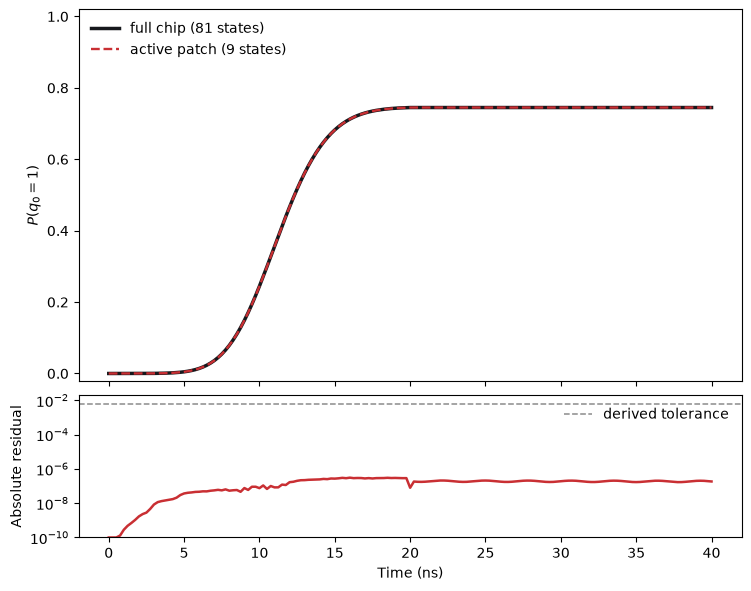

In [7]:
figure, (population_axis, residual_axis) = plt.subplots(
    2,
    1,
    figsize=(7.4, 5.8),
    height_ratios=(3.0, 1.15),
    sharex=True,
    layout="constrained",
)

population_axis.plot(times, full_population, color="#16181C", linewidth=2.5, label="full chip (81 states)")
population_axis.plot(
    times,
    reduced_population,
    color="#C92F33",
    linewidth=1.7,
    linestyle="--",
    label="active patch (9 states)",
)
population_axis.set_ylabel(r"$P(q_0=1)$")
population_axis.set_ylim(-0.02, 1.02)
population_axis.legend(frameon=False, loc="upper left")

display_residual = np.maximum(population_residual, 1.0e-10)
residual_axis.semilogy(times, display_residual, color="#C92F33", linewidth=1.8)
residual_axis.axhline(residual_tolerance, color="0.55", linestyle="--", linewidth=1.1, label="derived tolerance")
residual_axis.set(
    xlabel="Time (ns)",
    ylabel="Absolute residual",
    ylim=(1.0e-10, 2.0e-2),
)
residual_axis.legend(frameon=False, loc="upper right")

figure_path = "../docs/images/reduce_and_replay.png"
figure.savefig(figure_path, dpi=180)
plt.show()

The receipt records both the approximation's own validity and the independent
forward comparison.

In [8]:
reduction_receipt = {
    "active_labels": list(patch.active_labels),
    "all_folds_valid": all_folds_valid,
    "eliminated_labels": list(patch.eliminated_labels),
    "figure": figure_path,
    "full_dimension": full_dimension,
    "maximum_population_residual": maximum_residual,
    "maximum_g_over_delta": max_g_over_delta,
    "minimum_block_gap_ghz": minimum_block_gap,
    "original_chip_unchanged": tuple(device.label for device in chip.devices) == ("q0", "q1", "q2", "q3"),
    "peak_full_population": float(np.max(full_population)),
    "reduced_dimension": reduced_dimension,
    "reduction_method": "sw",
    "residual_tolerance": residual_tolerance,
    "same_schedule": same_schedule,
}

print(f"RESULT reduction={json.dumps(reduction_receipt, sort_keys=True, separators=(',', ':'))}")

RESULT reduction={"active_labels":["q0","q1"],"all_folds_valid":true,"eliminated_labels":["q3","q2"],"figure":"../docs/images/reduce_and_replay.png","full_dimension":81,"maximum_g_over_delta":0.011430064334933494,"maximum_population_residual":3.0859756261492066e-07,"minimum_block_gap_ghz":0.3499542857142881,"original_chip_unchanged":true,"peak_full_population":0.7449359918451395,"reduced_dimension":9,"reduction_method":"sw","residual_tolerance":0.006530604503289336,"same_schedule":true}


## What to change

Change `hops` to choose how much of the coupling neighbourhood remains
explicit. Change the spectator detunings or couplings and read the returned
validity record before trusting the smaller model.